In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [21]:
ruta=r"C:\Users\josegutjim\OneDrive - colsubsidio.com\Documents\Proyecto\steam-200k.csv"
df = pd.read_csv(ruta, header=None,
                  names=["user_id", "game", "behavior", "value", "extra"])

df.head()

,user_id,game,behavior,value,extra
0,151603712,The Elder Scrolls V Skyrim,purchase,1.0,0
1,151603712,The Elder Scrolls V Skyrim,play,273.0,0
2,151603712,Fallout 4,purchase,1.0,0
3,151603712,Fallout 4,play,87.0,0
4,151603712,Spore,purchase,1.0,0


1.Exploración de los datos

In [22]:

print("Dimensiones del dataset:", df.shape)
print("\nTipos de variables:\n", df.dtypes)
print("\nValores nulos:\n", df.isnull().sum())
print("\nRegistros duplicados:", df.duplicated().sum())
print("\nEstadísticos descriptivos:\n", df.describe())



Dimensiones del dataset: (200000, 5)

Tipos de variables:
 user_id       int64
game         object
behavior     object
value       float64
extra         int64
dtype: object

Valores nulos:
 user_id     0
game        0
behavior    0
value       0
extra       0
dtype: int64

Registros duplicados: 707

Estadísticos descriptivos:
             user_id          value     extra
count  2.000000e+05  200000.000000  200000.0
mean   1.036559e+08      17.874384       0.0
std    7.208074e+07     138.056952       0.0
min    5.250000e+03       0.100000       0.0
25%    4.738420e+07       1.000000       0.0
50%    8.691201e+07       1.000000       0.0
75%    1.542309e+08       1.300000       0.0
max    3.099031e+08   11754.000000       0.0


In [23]:
df[df["behavior"] == "purchase"]["value"].unique()

array([1.])

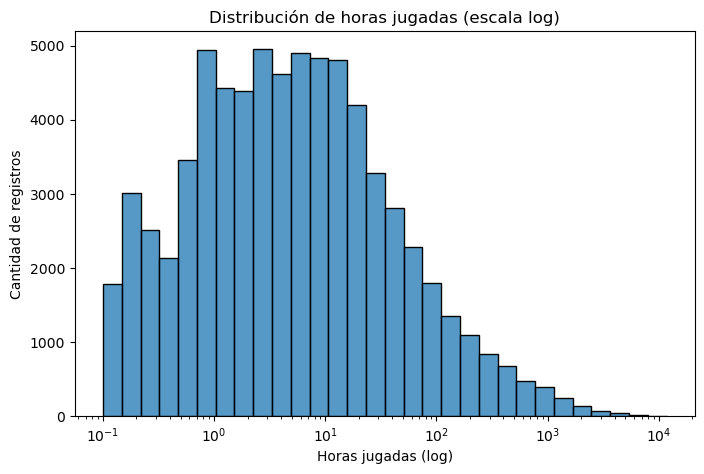

In [24]:
#• Visualizaciones que permitan comprender la información. 

df_play = df[df["behavior"] == "play"]

# Paso 2: graficar el histograma
plt.figure(figsize=(8, 5))
sns.histplot(data=df_play, x="value", log_scale=True, bins=30)
plt.title("Distribución de horas jugadas (escala log)")
plt.xlabel("Horas jugadas (log)")
plt.ylabel("Cantidad de registros")
plt.show()

2.Preparación de los datos

In [25]:
#Eliminación de variables irrelevantes. 
df = df.drop(columns=["extra"])

In [26]:
#Transformación del dataset para obtener variables por usuario. 
horas_por_usuario = df[df["behavior"] == "play"].groupby("user_id")["value"].sum()

In [27]:
n_juegos_por_usuario = df[df["behavior"] == "purchase"].groupby("user_id")["game"].count()

In [28]:
usuarios = n_juegos_por_usuario.to_frame(name="n_juegos").join(
    horas_por_usuario.to_frame(name="horas_totales"),
    how="left"
)
usuarios["horas_totales"] = usuarios["horas_totales"].fillna(0)

In [29]:
usuarios["horas_promedio_por_juego"] = usuarios["horas_totales"] / usuarios["n_juegos"]
usuarios.head()

,n_juegos,horas_totales,horas_promedio_por_juego
user_id,,,
5250,21,225.5,10.738095
76767,36,1227.0,34.083333
86540,82,255.0,3.109756
103360,10,0.0,0.000000
144736,8,0.1,0.012500


In [30]:
n_juegos_jugados = df[df["behavior"] == "play"].groupby("user_id")["game"].count()

In [31]:
usuarios = usuarios.join(n_juegos_jugados.to_frame(name="n_juegos_jugados"), how="left")
usuarios["n_juegos_jugados"] = usuarios["n_juegos_jugados"].fillna(0)

In [32]:
usuarios["pct_juegos_jugados"] = usuarios["n_juegos_jugados"] / usuarios["n_juegos"]

In [33]:
usuarios.head()

,n_juegos,horas_totales,horas_promedio_por_juego,n_juegos_jugados,pct_juegos_jugados
user_id,,,,,
5250,21,225.5,10.738095,6.0,0.285714
76767,36,1227.0,34.083333,20.0,0.555556
86540,82,255.0,3.109756,15.0,0.182927
103360,10,0.0,0.000000,0.0,0.000000
144736,8,0.1,0.012500,1.0,0.125000


In [34]:
usuarios["log_n_juegos"] = np.log1p(usuarios["n_juegos"])
usuarios["log_horas_totales"] = np.log1p(usuarios["horas_totales"])
usuarios["log_horas_promedio"] = np.log1p(usuarios["horas_promedio_por_juego"])

In [35]:
usuarios.describe()

,n_juegos,horas_totales,horas_promedio_por_juego,n_juegos_jugados,pct_juegos_jugados,log_n_juegos,log_horas_totales,log_horas_promedio
count,12393.000000,12393.000000,12393.000000,12393.000000,12393.00000,12393.000000,12393.000000,12393.000000
mean,10.450335,278.009021,55.426889,5.687808,0.72587,1.481543,3.067991,2.161558
std,35.864269,760.270618,241.287824,17.082134,0.34496,1.063936,2.434521,1.753850
min,1.000000,0.000000,0.000000,0.000000,0.00000,0.693147,0.000000,0.000000
25%,1.000000,1.300000,0.833333,1.000000,0.50000,0.693147,0.832909,0.606136
50%,2.000000,13.500000,5.650000,1.000000,1.00000,1.098612,2.674149,1.894617
75%,6.000000,155.600000,27.440000,3.000000,1.00000,1.945910,5.053695,3.347797
max,1075.000000,11754.000000,11754.000000,498.000000,1.00000,6.981006,9.372034,9.372034


3.Modelado

In [36]:
columnas_clustering = ["log_n_juegos", "log_horas_totales", "log_horas_promedio", "pct_juegos_jugados"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(usuarios[columnas_clustering])

In [37]:
inercias = []
rango_k = range(1, 11)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)

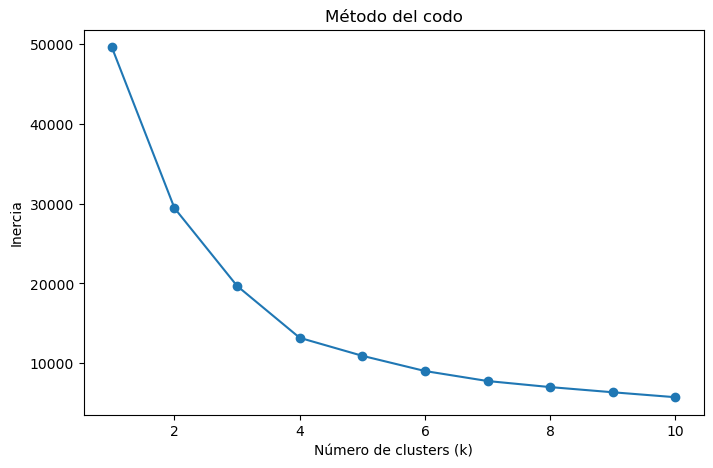

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercias, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

In [39]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
usuarios["cluster"] = kmeans_final.fit_predict(X_scaled)

In [40]:
usuarios["cluster"].value_counts()

cluster
0    4591
4    2394
1    1950
3    1908
2    1550
Name: count, dtype: int64

In [41]:
resumen_clusters = usuarios.groupby("cluster")[
    ["n_juegos", "horas_totales", "horas_promedio_por_juego", "pct_juegos_jugados"]
].mean()

resumen_clusters

,n_juegos,horas_totales,horas_promedio_por_juego,pct_juegos_jugados
cluster,,,,
0,1.264213,5.288347,4.284367,0.992631
1,3.752308,1.175846,0.280498,0.153634
2,61.794194,1337.362000,40.001499,0.595046
3,7.661950,93.553616,15.081357,0.524570
4,2.502089,487.628530,240.564487,0.925546


4.Interpretación de los clusters

Cluster     |	Usuarios    |     Nombre	|   Perfil
0 |	4,591	|   Jugador Enfocado / Casual	|   Pocos juegos, pero usa casi el 100% de lo que compra

1 |	1,950	|    Comprador Pasivo	        |   Compra algunos juegos, casi nunca los juega (15% de uso)

2 |	1,550	|    Coleccionista Activo	    |   Muchos juegos (62), muchas horas totales, usa el 60%

3 |	1,908	|   Equilibrado                 |	Punto medio en todo, sin comportamientos extremos

4 |	2,394	|   Jugador Muy Dedicado        |	Pocos juegos, pero se clava cientos de horas en cada uno

5.Recomendaciones de negocio

Estrategia de marketing por segmento

Cluster 0 — Jugador Enfocado/Casual (pocos juegos, usa el 99%): recomendaciones personalizadas basadas en lo poco que ya juega, ya que se sabe que sí consume lo que se le ofrece.

Cluster 1 — Comprador Pasivo (compra pero casi no juega, 15% de uso): campañas de activación, no de venta — recordatorios de biblioteca pendiente y recompensas por abrir juegos ya comprados.

Cluster 2 — Coleccionista Activo (62 juegos, usa 60%, muchas horas totales): activación de la biblioteca pendiente (tienen ~25 juegos sin abrir), con menor urgencia que el Cluster 1 porque ya consumen bastante en total.

Cluster 3 — Equilibrado (sin comportamientos extremos): recomendaciones genéricas basadas en popularidad o en lo más parecido a lo que ya juega — es el segmento "estándar".

Cluster 4 — Jugador Muy Dedicado (pocos juegos, ~240 horas cada uno, 92% de uso): recomendaciones muy dirigidas al mismo género de los juegos en los que ya invierte tanto tiempo.

Tipo de promoción por segmento

Cluster 0: descuentos en títulos similares.

Cluster 1: notificaciones tipo "llevas meses sin abrir X" + pequeñas recompensas (logros, puntos) por probar lo ya comprado.

Cluster 2: recordatorios de biblioteca pendiente, sin presión de nuevas compras.

Cluster 3: promociones estándar de la plataforma (ofertas generales, destacados).

Cluster 4: preventas o lanzamientos anticipados del mismo género que ya domina.

Priorización para fidelización

El Cluster 4 es la prioridad principal: usa el 92% de lo que compra, muy por encima del 60% del Cluster 2 — señal de que su inversión de tiempo se traduce en consumo real.